## **Lorenz Network Model Learned by SREINet**

## **I. Setup and Preprocessing**

In [84]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../../utilities"))

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Generated ER network with 15 nodes and 40 edges


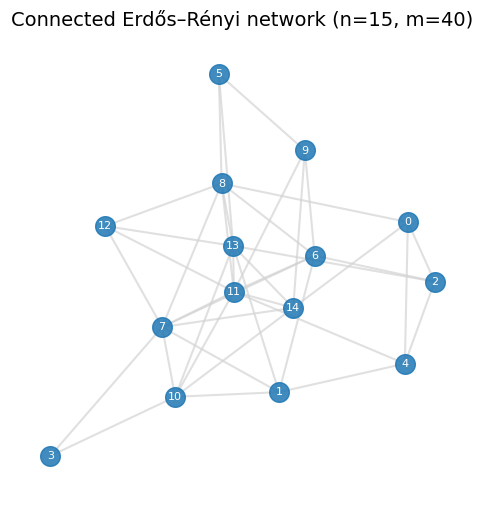

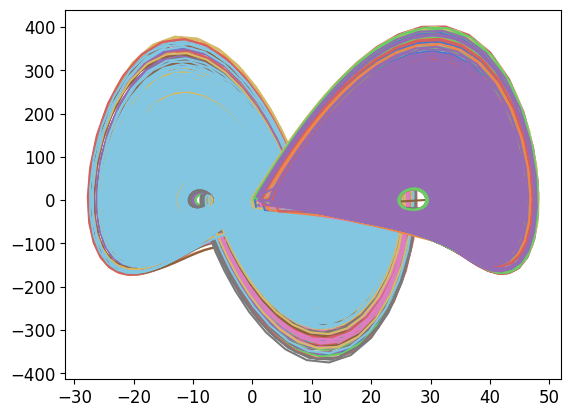

Training input shape: (75000, 45)
Training output shape: (75000, 45)


In [85]:
# Specify the model type
from lorenz_network import lorenz_network
from network_generator import generate_erdos_renyi_network, visualize_network

MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)

# Generate data based on the specified model type
n_nodes = 15
edge_probability = 0.4
seed = 42

edge_list, adjacency, degrees = generate_erdos_renyi_network(n_nodes, edge_probability, seed=seed)
visualize_network(edge_list, n_nodes)
print(f"Generated ER network with {n_nodes} nodes and {edge_list.shape[0]} edges")

np.random.seed(seed)
num_traj = 5

initial_conditions = []
for _ in range(num_traj):
    x0 = np.random.uniform(-5.0, 5.0, size=n_nodes)
    y0 = np.random.uniform(-5.0, 5.0, size=n_nodes)
    z0 = np.random.uniform(0.0, 5.0, size=n_nodes)
    initial_state = np.concatenate([x0, y0, z0])
    initial_conditions.append(initial_state)

data_T = 150.0       # Length of the data (T)
data_dt = 0.01      # Resolution of the data (dt)
myDG = DG.DataGenerator(initial_conditions, T=data_T, dt=data_dt, derivative_mode="exact")

def lorenz_vector_field(t, state, edge_list):
    return lorenz_network(t, state, edge_list, coupling_strength=0.1,coupling_type='diffusive')

t_arr, x_train, dx_train = myDG.generate_dataset_by_custom_ODEs(
    lorenz_vector_field,
    edge_list,
    method='RK45'
)

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train
training_input_for_sim = training_input.copy()  # Save a copy for validation

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

MY_MODEL = "Lorenz network (ER)"
data_initial_conditions = initial_conditions
ode_function = lorenz_vector_field
network_arguments = (edge_list,)


### **1.3 Hyperparameters**


In [86]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [87]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

guessed_multiplicative_order = 2
# The grid size of each dimension
layer_depth = guessed_multiplicative_order
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # these numbers exclude the constant term

[45, 45]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [88]:
my_activation = [lambda x:x,
                #lambda x:tf.sin(x),
                #lambda x:tf.cos(x),
                ]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-5, seed=42),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model.summary()
model = tf.keras.Model(inputs=inputs, outputs=output)



Model: "SREINet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 first_hidden_layer_7 (Firs  multiple                  0         
 tHiddenLayer)                                                   
                                                                 
 subsequent_hidden_layer_13  multiple                  2116      
  (SubsequentHiddenLayer)                                        
                                                                 
 dense_7 (Dense)             multiple                  46        
                                                                 
Total params: 2162 (8.45 KB)
Trainable params: 2116 (8.27 KB)
Non-trainable params: 46 (184.00 Byte)
_________________________________________________________________


### **2.2 Loss Function**

In [89]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [90]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**


In [91]:
np.set_printoptions(threshold=np.inf)

from sreinet_trainer import SREINetTrainer

trainer = SREINetTrainer(
    model,
    my_optimizer,
    loss_fn,
    data_type=MY_DATA_TYPE,
    random_seed=42,
)


## **III.Training the Model**

#### **Pruning Profile**

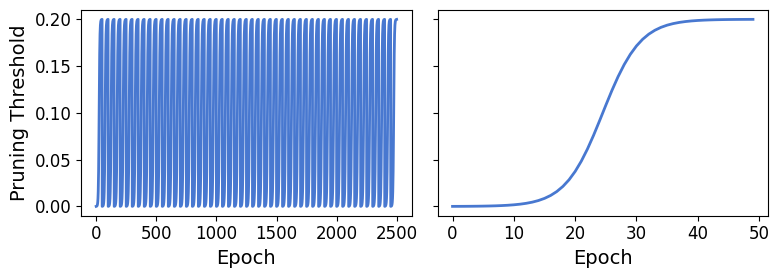

In [92]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.20 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 50
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(
    steps_per_period=PRUNING_EPOCHS_PER_PERIOD,
    num_periods=N_PERIODS,
    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
    ramp_type = 'sigmoid',
    show_plot=True,
    sigmoid_steepness=15.0,
    #zero_percentage=.2,
    #ramp_percentage=0.75,
)


### Training

In [93]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 5e-9   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.005

training_histories = []
weights_list = []

In [94]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(0, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    trainer.reset_trainer_and_model_weights(i)
    output = training_output[:, i:i+1]

    history = trainer.fit(
        training_input,
        output,
        batch_size=MINI_BATCH_SIZE,
        validation_split=0.20,
        epochs=round(NUM_EPOCHS),
        pruning_scheduler=pruning_scheduler,
        callbacks=callbacks,
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
        shuffle_per_epoch=False,
        patience_periods=10,
        verbose=1,
    )

    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])


Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 2.860e+02,  Validation Loss: 9.388e+01,  Epoch Time: 0.65s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 1.228e+02,  Validation Loss: 1.184e+02,  Epoch Time: 0.47s,  Current Pruning Threshold: 2.5904e-05
Epoch   3 (Period 1):  Train Loss: 9.573e+01,  Validation Loss: 2.734e+02,  Epoch Time: 0.46s,  Current Pruning Threshold: 6.1801e-05
Epoch   4 (Period 1):  Train Loss: 1.317e+02,  Validation Loss: 6.456e+01,  Epoch Time: 0.45s,  Current Pruning Threshold: 0.00011154
Epoch   5 (Period 1):  Train Loss: 1.561e+02,  Validation Loss: 9.465e+02,  Epoch Time: 0.45s,  Current Pruning Threshold: 0.00018044
Epoch   6 (Period 1):  Train Loss: 1.308e+02,  Validation Loss: 6.644e+01,  Epoch Time: 0.46s,  Current Pruning Threshold: 0.00027587
Epoch   7 (Period 1):  Train Loss: 6.708e+01,  Validation Loss: 9.920e+01,  Epoch Time: 0.45s,  Current Pruning Threshold: 0.000408
Epoch   8 (Period 1):  Train Loss: 4.836e+01,  Va

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [95]:
def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [96]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [97]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' =  - 10.40000057*x1 + 0.09999995679*x3 + 0.1000000499*x5 + 0.09999998659*x9 + 0.1000000052*x15 + 9.999999523*x16
(x2)' =  - 10.49998331*x2 + 0.100000158*x5 + 0.09999991208*x7 + 0.09999944642*x8 + 0.1000000574*x11 + 0.1000000164*x14 + 9.999985695*x17
(x3)' = 0.1000000015*x1 - 10.39999962*x3 + 0.09999996051*x5 + 0.09999997541*x7 + 0.1000000276*x14 + 10*x18
(x4)' =  - 10.20000076*x4 + 0.09999977052*x8 + 0.09999998286*x11 + 10*x19
(x5)' = 0.09999994934*x1 + 0.09999992326*x2 + 0.09999995306*x3 - 10.39999771*x5 + 0.09999991208*x12 + 9.999998093*x20
(x6)' =  - 10.3000021*x6 + 0.1000000574*x9 + 0.09999993443*x10 + 0.09999999031*x14 + 10.00000143*x21
(x7)' = 0.09999995679*x2 + 0.1000000052*x3 - 10.59999943*x7 + 0.1000000462*x8 + 0.1000000052*x9 + 0.100000117*x10 + 0.09999994561*x12 + 10*x22
(x8)' = 0.09999995306*x2 + 0.09999997914*x4 + 0.100000035*x7 - 10.80000114*x8 + 0.09999997914*x9 + 0.1000000462*x11 + 0.09999996424*x12 + 0.09999995306*x13 + 0.1000000089*x15 + 10.00000048*x23
(x9)' = 

### **Validation**

In [102]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);


### Comparing vector field

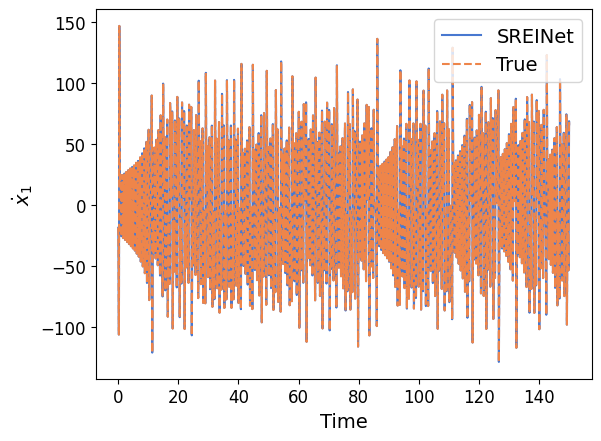

In [103]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [106]:
val_t_span = [0,20]
val_t_eval = np.arange(0,20,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

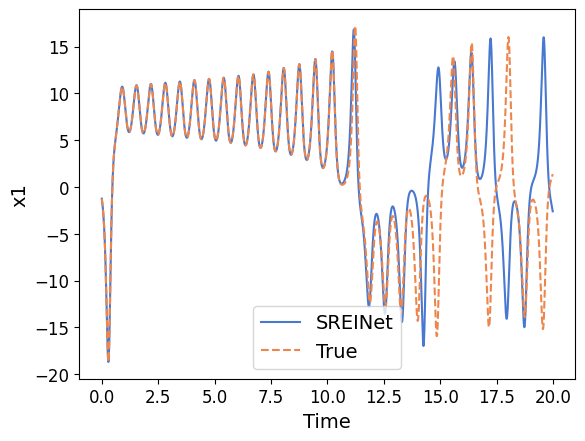

In [107]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()



In [108]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")

complexity_per_dimension = complexity // dim
print(f"complexity per dimension: {complexity_per_dimension}")


Score: 0.9999924405294099
Complexity: 187
complexity per dimension: 4


## **VI. Output**

In [111]:
#save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Total Training Epochs': [NUM_EPOCHS],
    'loss function': [LOSS_FUNCTION],
    'max weight threshold for pruning': [MAX_WEIGHT_PRUNING_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
    'pruning epochs per period': [PRUNING_EPOCHS_PER_PERIOD],
    'number of training periods': [N_PERIODS],
})

In [ ]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='Lorenz_network_nn_configurations.xlsx',
    output_dir='output'
)